### Example 1: autocorrelation of structured vs random signals

Autocorrelation gives us a measure of “self-similarity over shifts or lags”. For
instance, a periodic signal will have similarly spaced peaks, while random
signals will not.

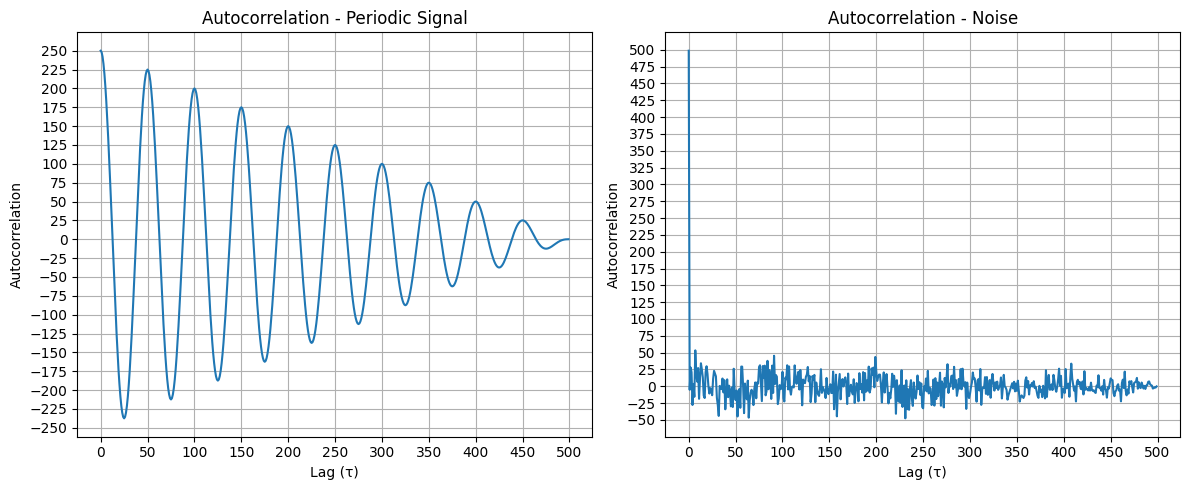

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

np.random.seed(0)

N = 500

# Periodic signal
t = np.arange(N)
x_periodic = np.sin(2 * np.pi * t / 50)

# Random signal
x_noise = np.random.randn(N)

def autocorr(x):
    result = correlate(x, x, mode='full')
    return result[result.size // 2:]

lags = np.arange(N)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.grid(True)
plt.xticks(np.arange(0, N+1, 50))
plt.yticks(np.arange(-250, 250+1, 25))
plt.xlabel("Lag (τ)")
plt.ylabel("Autocorrelation")
plt.plot(lags, autocorr(x_periodic))
plt.title("Autocorrelation - Periodic Signal")

plt.subplot(1,2,2)
plt.grid(True)
plt.xticks(np.arange(0, N+1, 50))
plt.yticks(np.arange(-50, 500+1, 25))
plt.xlabel("Lag (τ)")
plt.ylabel("Autocorrelation")
plt.plot(lags, autocorr(x_noise))
plt.title("Autocorrelation - Noise")

plt.tight_layout()
plt.show()

Above we can see three signal characteristics that the autocorrelation can
provide: 
1) if the signal has periodicity, the autocorrelation spikes at multiples
of the period. (left chart, with the sinusoid);
2) now, if the signal has memory (correlation structure) it presents a slow decay
   (again, left chart);
3) finally, if the signal is random (white noise) it only peaks at lag = 0 (right chart, with the random gaussian noise).

### Example 2: cross-correlation for delay estimation

The cross-correlation measures the “similarity between two signals”. With it one
can detect the relationships between two signals, for instance if they are
direct, inversely or not proportinal among each other. Also, if there is a time
delay between them, like in the example below: 

In [89]:
import ipywidgets as widgets
from IPython.display import display

x = np.sin(2 * np.pi * t / 40)
n = np.arange(len(x))
lags = np.arange(-len(x) + 1, len(x))

def plot_cross_correlation(delay):
    y = np.roll(x, delay)
    corr = correlate(y, x, mode='full')
    estimated_delay = lags[np.argmax(corr)] # type: ignore

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)

    axes[0].plot(lags, corr, color='tab:green', label='Cross-correlation')
    axes[0].axvline(
        x=estimated_delay,
        color='red',
        linestyle='--',
        linewidth=2,
        label='Time delay estimate'
    )
    axes[0].grid(True)
    axes[0].set_xticks(np.arange(-N, N + 1, 20))
    axes[0].tick_params(axis='x', rotation=90)
    axes[0].set_yticks(np.arange(-250, 250 + 1, 25))
    axes[0].set_xlabel('Lag')
    axes[0].set_ylabel('Cross-correlation')
    axes[0].set_title(
        f'Cross-correlation (real delay = {delay}, estimated delay = {estimated_delay})'
    )
    axes[0].legend(loc='upper right')

    axes[1].plot(n, x, label='x[n] (reference)', color='tab:blue')
    axes[1].grid(True)
    axes[1].set_xticks(np.arange(0, N + 1, 10))
    axes[1].tick_params(axis='x', rotation=90)
    axes[1].set_yticks(np.arange(-1, 1.1, 0.5))
    axes[1].set_ylabel('Amplitude')
    axes[1].set_title('Reference signal x[n]')
    axes[1].legend(loc='upper right')

    axes[2].plot(n, y, label=f'y[n] = x[n-{delay}] (shifted)', color='tab:orange')
    axes[2].grid(True)
    axes[2].set_xticks(np.arange(0, N + 1, 10))
    axes[2].tick_params(axis='x', rotation=90)
    axes[2].set_yticks(np.arange(-1, 1.1, 0.5))
    axes[2].set_ylabel('Amplitude')
    axes[2].set_title('Shifted signal y[n]')
    axes[2].legend(loc='upper right')

    

    plt.tight_layout()
    plt.show()

delay_slider = widgets.IntSlider(
    value=20,
    min=-80,
    max=80,
    step=20,
    description='Delay',
    continuous_update=True
)

interactive_plot = widgets.interactive_output(
    plot_cross_correlation,
    {'delay': delay_slider}
 )

display(delay_slider, interactive_plot)

IntSlider(value=20, description='Delay', max=80, min=-80, step=20)

Output()

### Example 3: cross-correlation on features of a real dataset

In this notebook, we analyze the autocorrelation of the Sunspots dataset (we
have access to it using the "statsmodels" package). In it
we can see how periodic behavior appears in autocorrelation

This dataset represents a "quasi-periodic stochastic process", meaning that it has
a dominant cycle, but it is not perfectly periodic, as will become apparent

In [ ]:
!pip install statsmodels

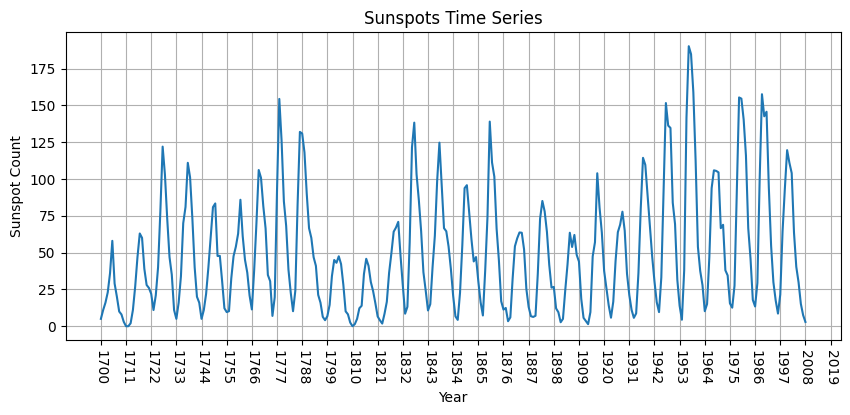

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.datasets import sunspots

# Load dataset
data = sunspots.load_pandas().data
years = data['YEAR'].values
x = data['SUNACTIVITY'].values

plt.figure(figsize=(10,4))
plt.plot(years, x)
plt.title("Sunspots Time Series")
plt.xticks(np.arange(1700, 2025, 11), rotation=-90)
plt.xlabel("Year")
plt.ylabel("Sunspot Count")
plt.grid()
plt.show()

Note the pattern that repeats around every 11 years, approximately.
This suggests the signal behaves approximately like a sinusoid which, as we saw,
can be described by:

x(t)=A(t)cos(wt + φ(t)) + noise

where there is variation on the amplitude and phase in regards to the time t.
An observation is that this is NOT a pure sinusoid, which is why autocorrelation
decays and gets near zero, as shown below:

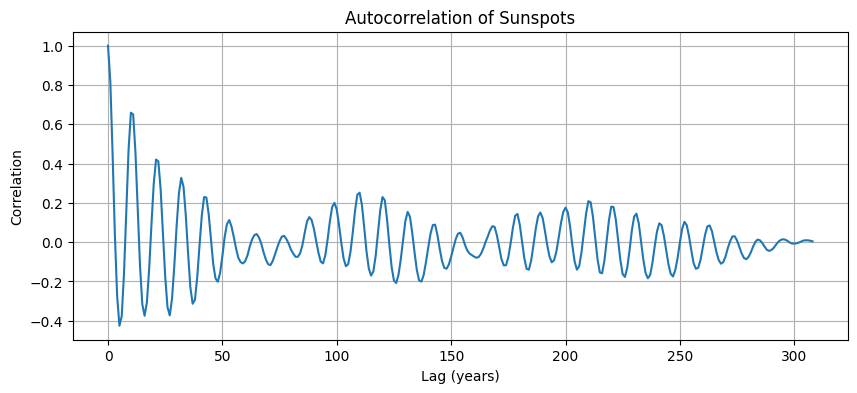

In [119]:
from scipy.signal import correlate

# Normalize signal
x_norm = (x - np.mean(x)) / np.std(x)

# Compute autocorrelation
corr = correlate(x_norm, x_norm, mode='full')
corr = corr[corr.size // 2:]
corr /= corr[0]

lags = np.arange(len(corr))

plt.figure(figsize=(10,4))
plt.plot(lags, corr)
plt.title("Autocorrelation of Sunspots")
plt.xlabel("Lag (years)")
plt.ylabel("Correlation")
plt.grid()
plt.show()

Now, also showing the peaks

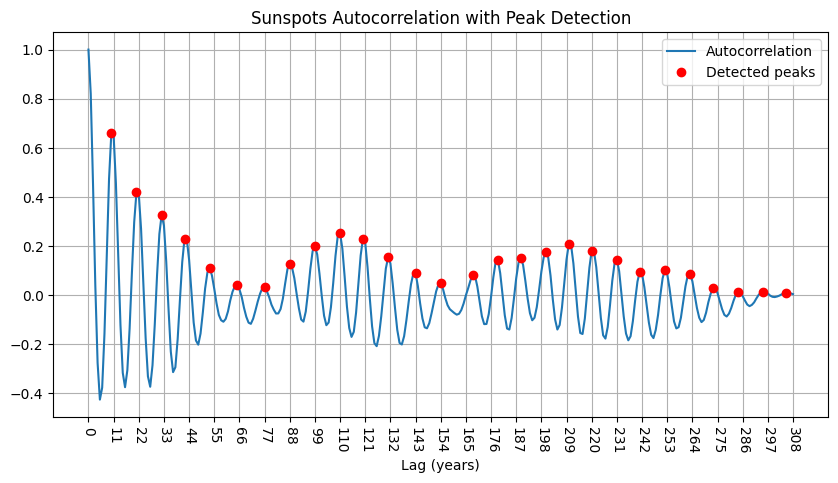

First few peak lags (years): [10 21 32 42 53]


In [121]:
data = sunspots.load_pandas().data
x = data['SUNACTIVITY'].values

# Normalize
x = (x - np.mean(x)) / np.std(x)

# Autocorrelation
corr = correlate(x, x, mode='full')
corr = corr[corr.size // 2:]
corr /= corr[0]

lags = np.arange(len(corr))

# Detect peaks
peaks, _ = find_peaks(corr, height=0)

plt.figure(figsize=(10,5))
plt.plot(lags, corr, label="Autocorrelation")
plt.plot(peaks, corr[peaks], 'ro', label="Detected peaks")

plt.title("Sunspots Autocorrelation with Peak Detection")
plt.xlabel("Lag (years)")
plt.xticks(np.arange(0, len(corr), 11), rotation=-90)
plt.grid()
plt.legend()
plt.show()

# Print first few peak locations
print("First few peak lags (years):", peaks[:5])

Autocorrelation measures how similar is the signal to itself after a shift. So, we can interpret that positive values indicate similar behavior and negative values indicate opposite behavior.

As the chart currently shows, the main peak (excluding the first one) appears
around ~11 years, which indicate the 11 year periodicity of this solar cycle.
This means that we need to look for multiples of 11 to catch years with high solar
activity. Also, when the autocorrelation goes negative, the info is that the
behavior is the opposite, therefore, we are aligning a peak with a valley and it
basically means that particular year in analysis will have low solar activity. From the
chart this seems to happen roughly around ~5 or ~6 years from the start and then
keeps repeating.

#### Also, remember that the Sunspots dataset is not a pure sinusoid:

This is because it has 1) amplitude A(t) that varies with time, 2) a slight frequency drift φ(t)
that varies with time as well, and also 3) contains noise, so alignment becomes imperfect over time.
The effect is that the peaks become smaller with time and the correlation decays.
As we saw from "example 1", this behavior from the autocorrelation indicates that
a) the process has memory and b) it has periodicity, but it is not perfect, though

Below, we can compare the dataset with a pure sinusoid:

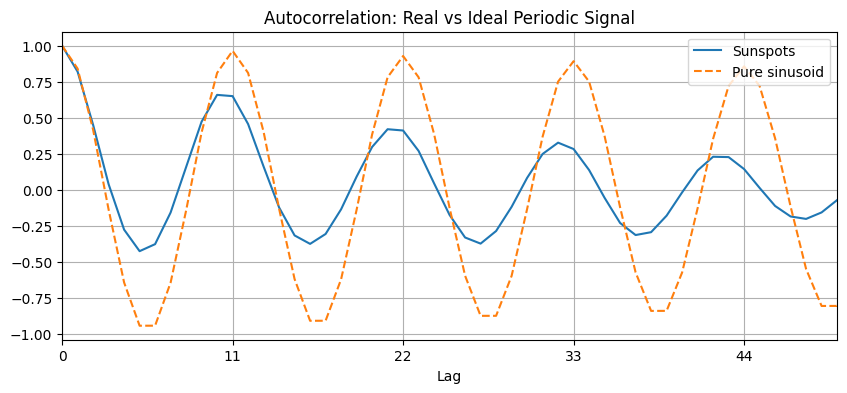

In [124]:
# Generate a pure sinusoid
t = np.arange(len(x))
T = 11  # period
sin_signal = np.sin(2 * np.pi * t / T)

# Normalize
sin_signal = (sin_signal - np.mean(sin_signal)) / np.std(sin_signal)

# Autocorrelation
corr_sin = correlate(sin_signal, sin_signal, mode='full')
corr_sin = corr_sin[corr_sin.size // 2:]
corr_sin /= corr_sin[0]

plt.figure(figsize=(10,4))
plt.plot(lags, corr[:len(lags)], label="Sunspots")
plt.plot(lags, corr_sin[:len(lags)], '--', label="Pure sinusoid")

plt.xlim(0, 50)
plt.title("Autocorrelation: Real vs Ideal Periodic Signal")
plt.xlabel("Lag")
plt.xticks(np.arange(0, 51, 11))
plt.grid()
plt.legend()
plt.show()